# 01 - Pipeline walkthrough

This notebook walks through the full **3DMPE** reconstruction pipeline one stage
at a time, using a procedurally generated *torus* so it runs with no downloads.

The idea: we never give the algorithm the 3D points. Instead we take several 2D
"photos" (rotated projections), reduce each to a matrix of pairwise distances,
and ask **MPSE** to recover a single 3D point cloud (plus one projection per
view) that is consistent with all of those distance matrices.

```
points -> perspectives -> visibility -> distance matrices -> MPSE -> align -> metrics
```

In [1]:
import numpy as np
import plotly.graph_objs as go

from mpe3d import datasets, views, reconstruct, build_distance_matrices
from mpe3d.visualization import plot_point_clouds, plot_cost_history

rng = np.random.default_rng(0)

## Step 1 - The ground-truth point cloud

We sample points from the surface of a torus. This is the shape we will try to
recover; the algorithm never sees it directly.

point cloud shape: (300, 3)


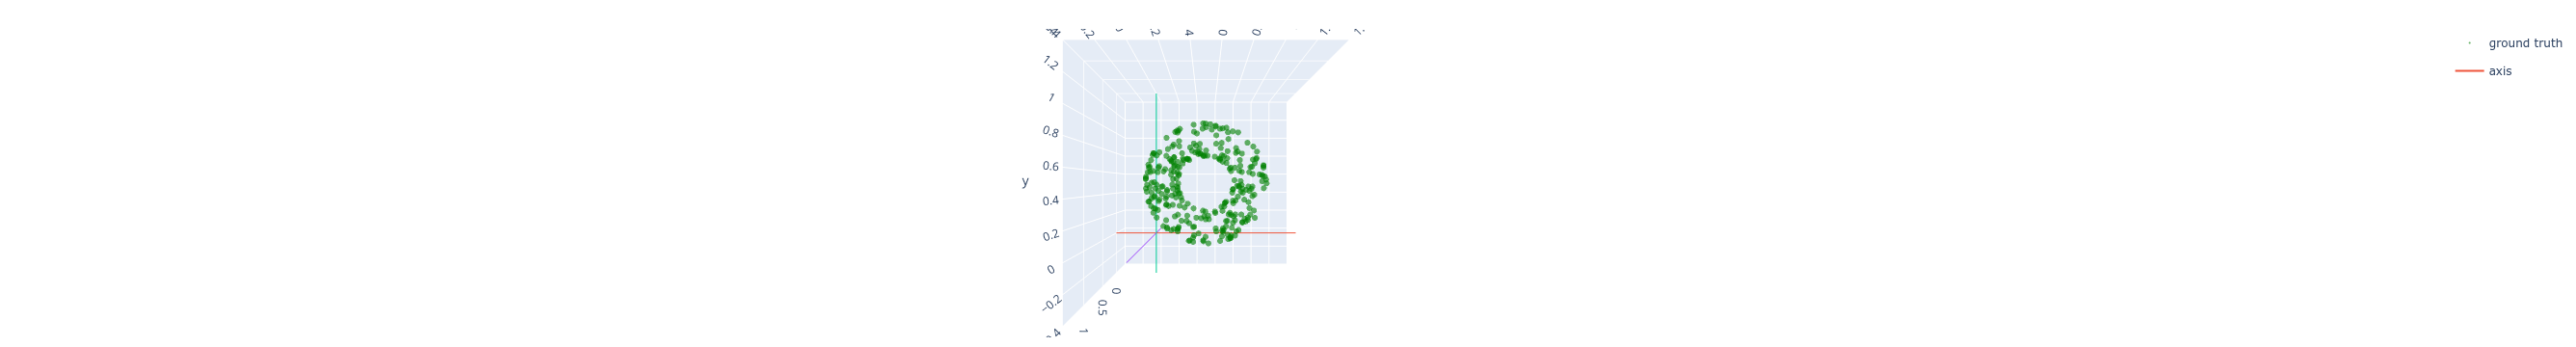

In [2]:
points = datasets.get_dataset_points("demo:torus", n_points=300, normalize=True)
print("point cloud shape:", points.shape)

plot_point_clouds([points], names=["ground truth"], colors=["green"])

## Step 2 - Simulate perspectives

We rotate the cloud about the Y axis to generate several camera views. Below we
plot the 2D image seen by each view.

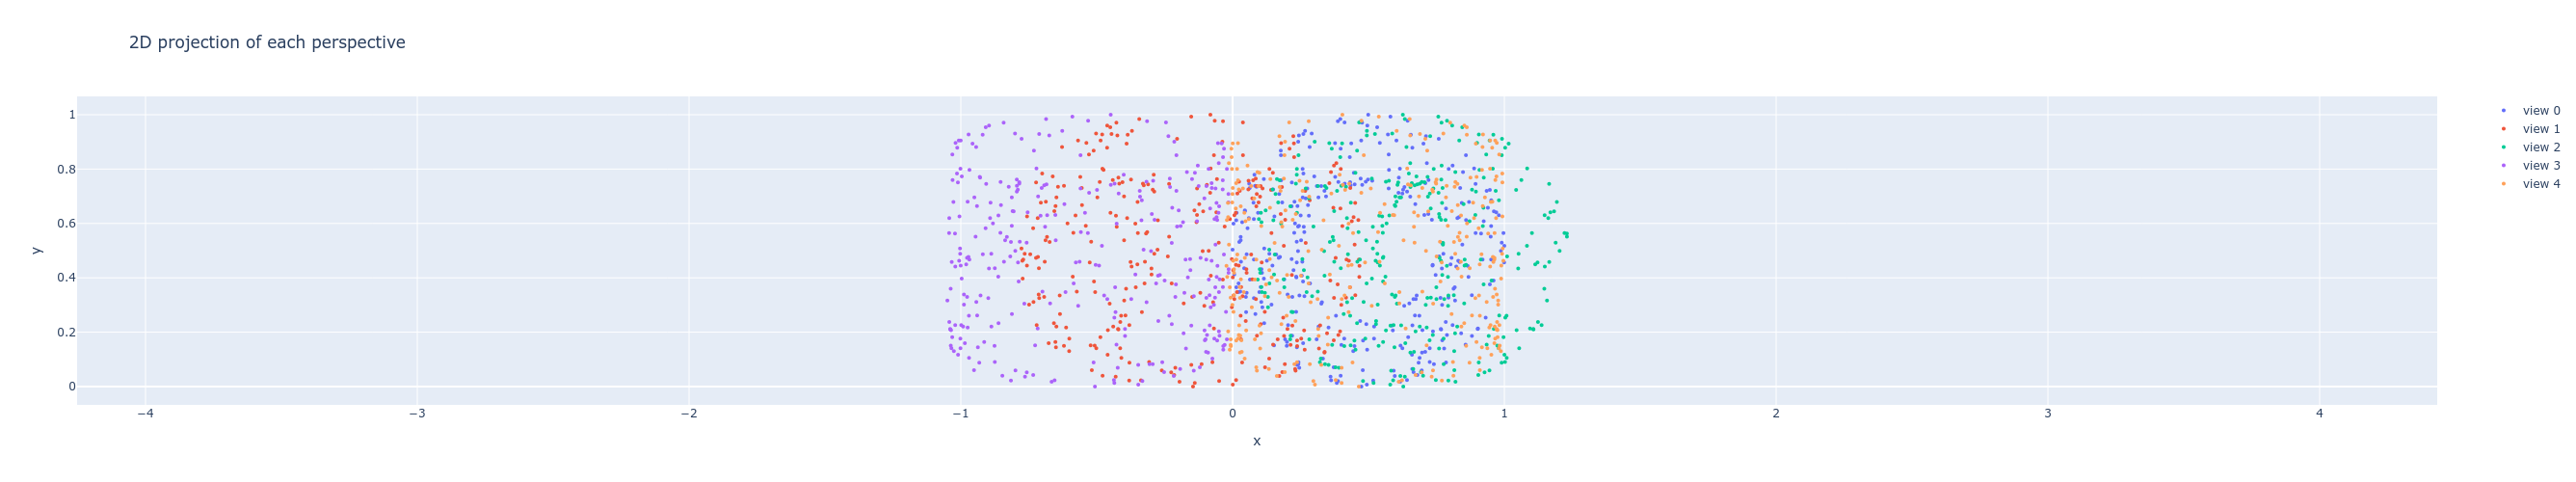

In [3]:
n_perspectives = 5
perspectives, projection_mats = views.randomized_perspectives(
    points, n_perspectives, angle_range=(0, 360), rng=rng)

fig = go.Figure()
for i, persp in enumerate(perspectives):
    fig.add_trace(go.Scatter(x=persp[:, 0], y=persp[:, 1], mode="markers",
                             name=f"view {i}", marker=dict(size=4)))
fig.update_layout(title="2D projection of each perspective",
                  xaxis_title="x", yaxis_title="y", width=650, height=500)
fig.update_yaxes(scaleanchor="x", scaleratio=1)
fig

## Step 3 - Visibility and distance matrices

Each point is made visible in only a few of the views (here, 3 of 5), and every
view is reduced to a matrix of pairwise 2D distances between its visible points.
These distance matrices are the only input MPSE receives.

5 distance matrices, each (300, 300)


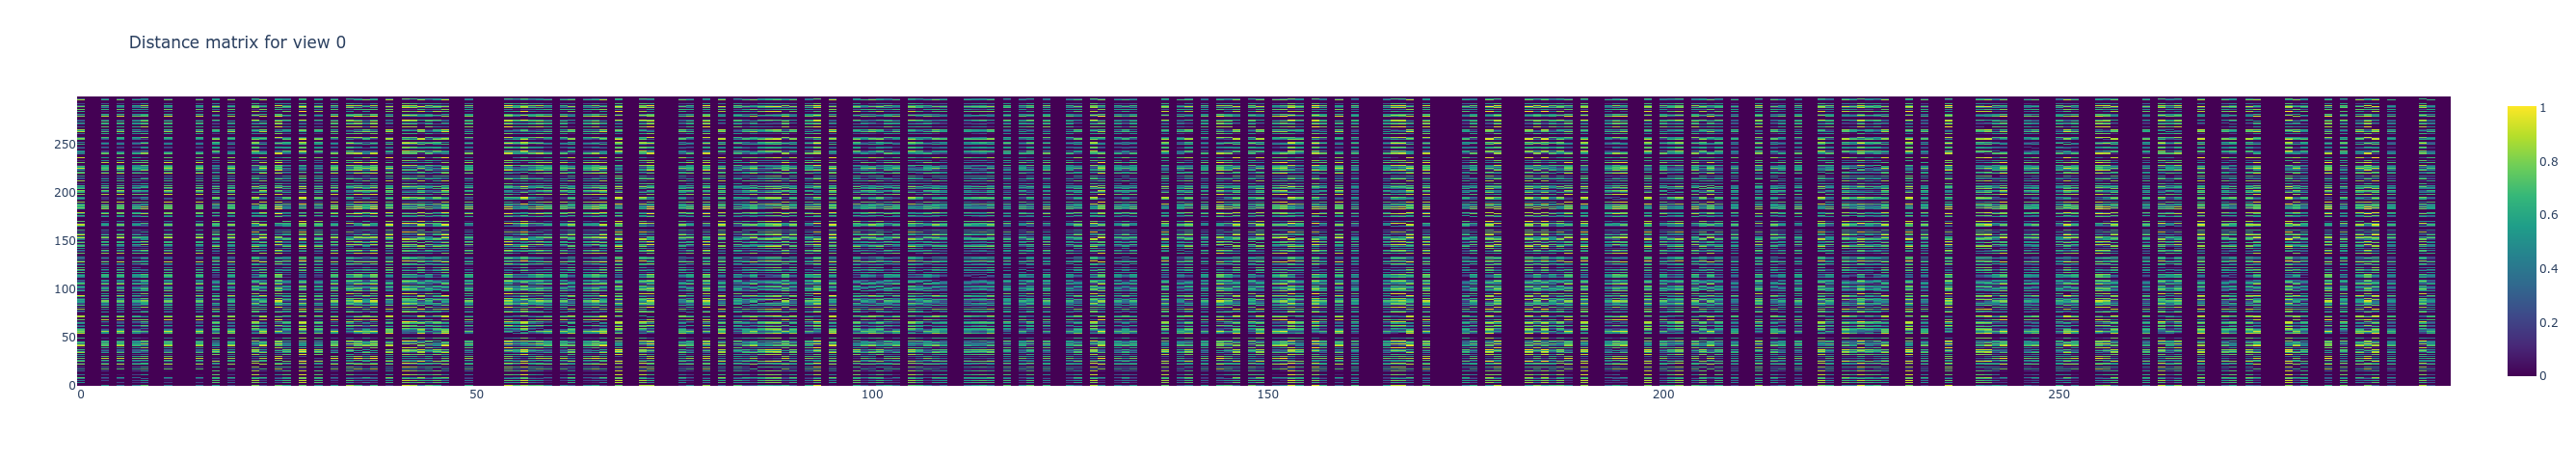

In [4]:
dist_mats, weight_mats, projection_mats = build_distance_matrices(
    points, n_perspectives=n_perspectives, projection="atleast",
    points_in_at_least=3, rng=np.random.default_rng(0))

print(f"{len(dist_mats)} distance matrices, each {dist_mats[0].shape}")

go.Figure(
    data=go.Heatmap(z=dist_mats[0], colorscale="Viridis"),
    layout=go.Layout(title="Distance matrix for view 0", width=520, height=480),
)

## Step 4 - Run MPSE

The `reconstruct` helper performs all of the above internally and then runs the
MPSE optimization, aligns the result to the ground truth, and computes error
metrics. We compare against a naive baseline (plain MDS on the averaged distance
matrix).

In [5]:
result = reconstruct(
    points,
    n_perspectives=n_perspectives,
    projection="atleast",
    points_in_at_least=3,
    batch_size=64,
    max_iter=150,
    verbose=0,
    rng=np.random.default_rng(0),
)

result.summary()

{'chamfer': np.float64(0.08630084191014045),
 'emd': np.float64(0.04315042095507022),
 'final_cost': 0.008112849614009175,
 'baseline_chamfer': np.float64(13.736932093254255),
 'baseline_emd': np.float64(9.647044564237547)}

## Step 5 - Reconstruction vs. ground truth

The reconstruction (red) is overlaid on the ground truth (green) after rigid
alignment. The MPSE Chamfer/EMD errors should be far smaller than the baseline's.

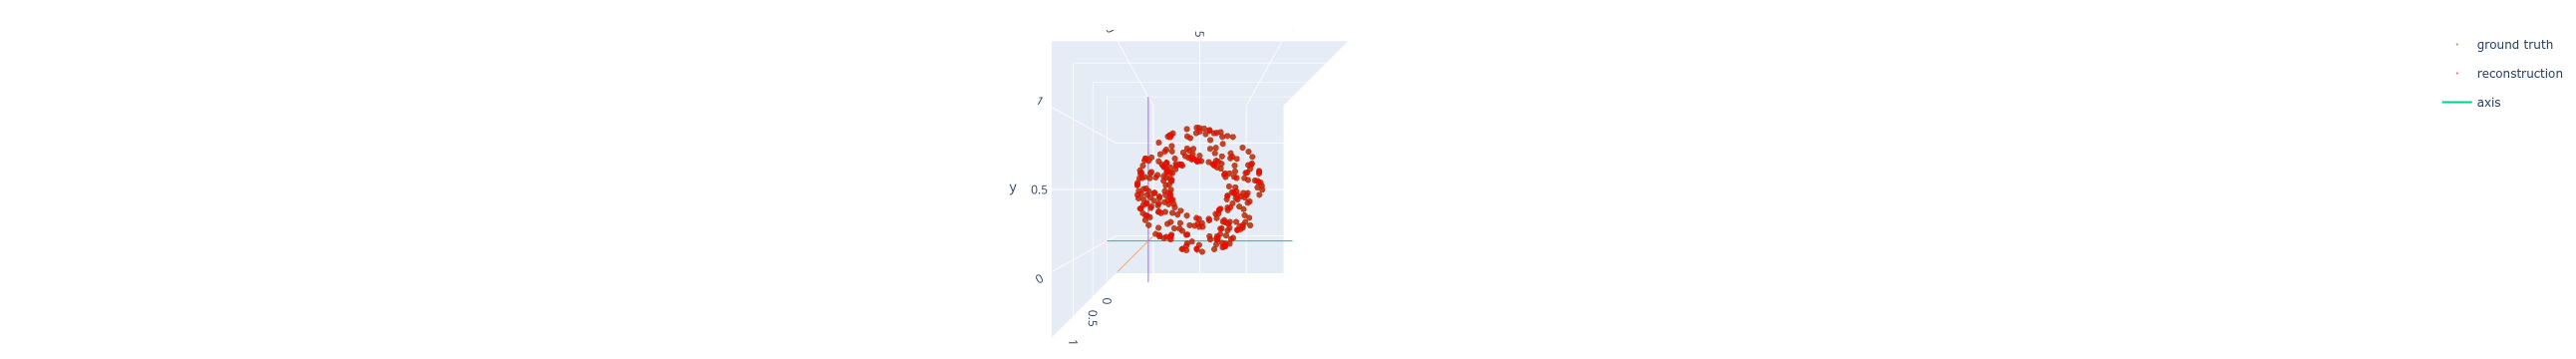

In [6]:
plot_point_clouds(
    [result.ground_truth, result.aligned_embedding],
    names=["ground truth", "reconstruction"],
    colors=["green", "red"],
)

## Step 6 - Optimization cost history

Finally, the MPSE stress (cost) as the optimization progresses.

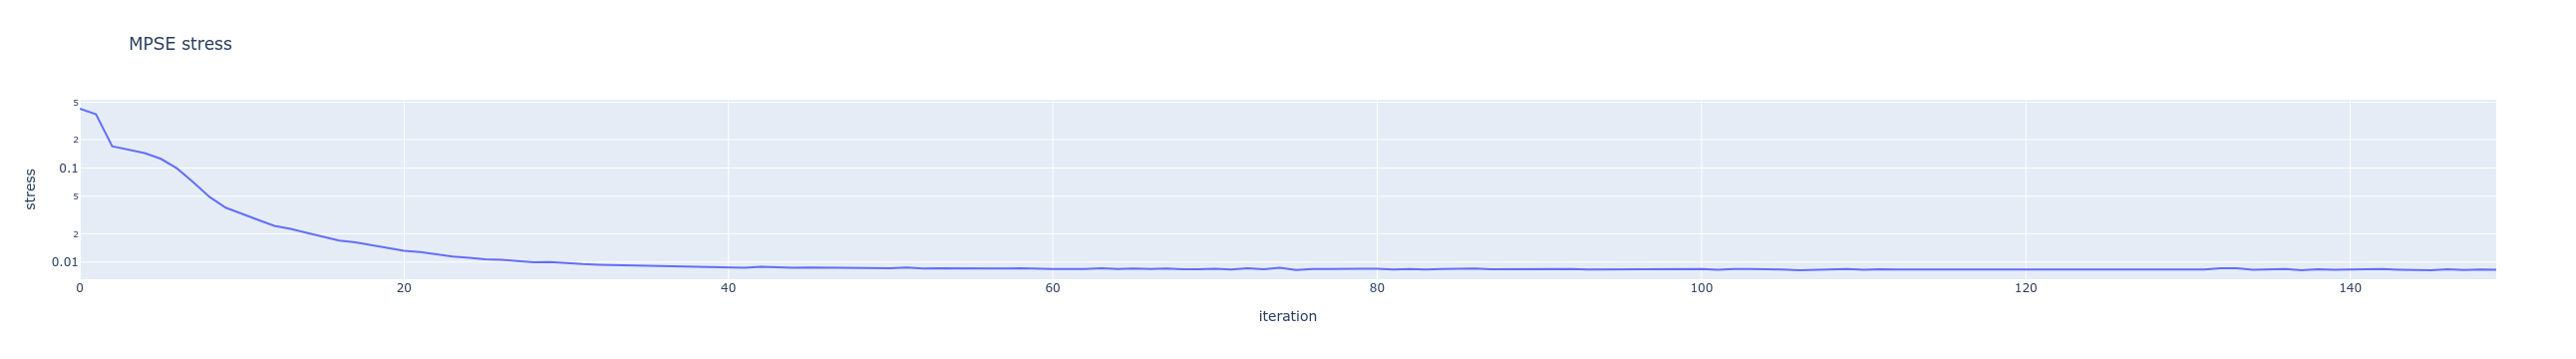

In [7]:
plot_cost_history(result.cost_history)